# T11d — Transformer (Encoder-only)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Encoder-only Transformer — multi-head self-attention over the W-cycle window. Mean-pools the sequence output before the regression head.

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")

Device: mps


In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False   # required for full reproducibility
print(f"Seeds fixed: {SEED}")


Seeds fixed: 42


## 1. Load data & build windows

In [4]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
Train batches: 342  Val batches: 1


## 2. Model definition

Encoder-only Transformer:
1. Linear projection: `n_features → d_model`
2. Learnable positional encoding (one embedding per cycle position)
3. Transformer encoder (multi-head self-attention)
4. Mean pool over the sequence → global context vector
5. Linear head → RUL

> **Why mean-pool instead of last timestep?**  
> Attention already weighs all positions; mean-pooling exploits the full context rather than ignoring earlier cycles.

In [5]:
from src.models.dl_architectures import TransformerModel


## 3. Train

In [6]:
model, train_losses, val_losses = train_model(
    model        = TransformerModel(n_features=N_FEATURES, d_model=64, dropout=0.1),
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "Transformer",
)

  [Transformer] Epoch  10 | train=2.8025 | val=0.7805 | best=0.7589  [NASALoss]
  [Transformer] Epoch  20 | train=1.8307 | val=0.5826 | best=0.4638  [NASALoss]
  [Transformer] Early stop at epoch 24


## 4. Evaluate

In [7]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="Transformer")
print(results)

# [Transformer] RMSE: 13.6526  |  NASA Score: 1015.02 (mean: 4.09)  |  R2: 0.8991  |  Bias: +1.87 (late ↑)

  [Transformer] RMSE: 14.4222  |  NASA Score: 1093.54 (mean: 4.41)  |  R2: 0.8874  |  Bias: -1.27 (early ↓)
{'rmse': 14.422187805175781, 'nasa_score': 1093.53564453125, 'nasa_score_mean': 4.409417921496976, 'r2_score': 0.8874083757400513, 'bias': -1.2726918458938599}


In [8]:
# ── Uncertainty: Monte Carlo Dropout ─────────────────────────────────────────
# Keep dropout active at inference → 30 stochastic passes → empirical Q10/Q50/Q90
from src.models.uncertainty import MCDropout
from src.evaluation.metrics import save_model_results, save_predictions_csv
import numpy as np

mc = MCDropout(model, p_drop=0.1)
q_low, q_mid, q_high, std_pred = mc.predict(X_test)

# Coverage and width
coverage  = float(np.mean((y_true >= q_low) & (y_true <= q_high)) * 100)
avg_width = float(np.mean(q_high - q_low))
print(f"[Transformer MC Dropout]  width: {avg_width:.1f} cycles   coverage: {coverage:.1f}%  (target 80%)")

# Persist to all_model_results.csv
save_model_results(
    model_name = "Transformer (MC Dropout)",
    model_type = "dl",
    y_true     = y_true,
    y_pred     = q_mid,
    y_lower    = q_low,
    y_upper    = q_high,
)

# Per-engine predictions with real uncertainty bounds
engine_ids = list(range(len(y_true)))
save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = q_mid,
    y_lower    = q_low,
    y_upper    = q_high,
    model_name = "Transformer (MC Dropout)",
)


[Transformer MC Dropout]  width: 31.0 cycles   coverage: 53.2%  (target 80%)
  [Transformer (MC Dropout)] RMSE: 15.1405  |  NASA Score: 1538.22 (mean: 6.20)  |  R2: 0.8759  |  Bias: +4.19 (late ↑)
  → Saved to results/all_model_results.csv

  [Transformer (MC Dropout)] Bound Validation Report (248 engines):
    ✓ negative_preds: 0
    ✓ over_cap_preds: 0
    ✓ inverted_bounds: 0
    ✓ pred_outside_interval: 0
    ✓ nan_or_inf: 0
    → All checks passed — predictions are numerically valid.
  → Saved 248 predictions to results/predictions/Transformer_MC_Dropout.csv
     Coverage: 53.2%  |  Avg interval width: 30.99 cycles


PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/predictions/Transformer_MC_Dropout.csv')

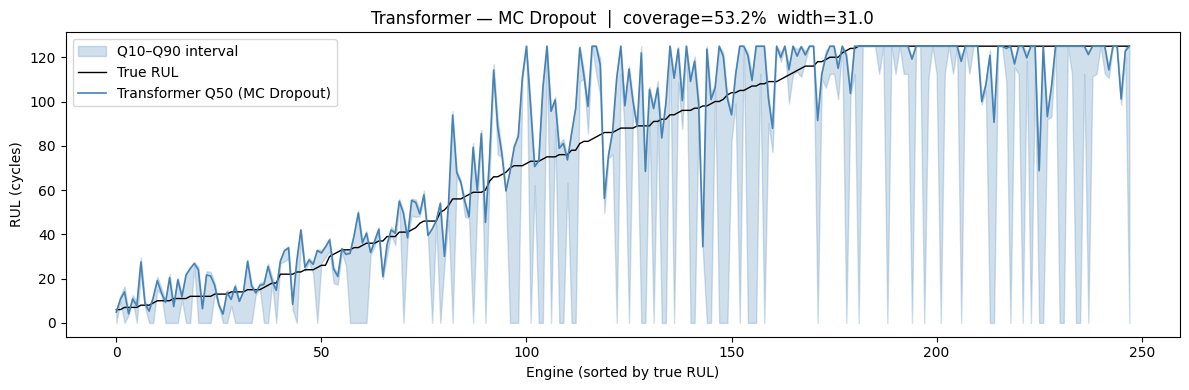

In [9]:
# Q10–Q90 uncertainty band — engines sorted by true RUL
import matplotlib.pyplot as plt
import numpy as np

order = np.argsort(y_true)
x, yt = np.arange(len(y_true)), y_true[order]
yp, ql, qh = q_mid[order], q_low[order], q_high[order]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(x, ql, qh, alpha=0.25, color="steelblue", label="Q10–Q90 interval")
ax.plot(x, yt, color="black",     lw=1,   label="True RUL")
ax.plot(x, yp, color="steelblue", lw=1.2, label="Transformer Q50 (MC Dropout)")
ax.set_xlabel("Engine (sorted by true RUL)")
ax.set_ylabel("RUL (cycles)")
ax.set_title(f"Transformer — MC Dropout  |  coverage={coverage:.1f}%  width={avg_width:.1f}")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
from src.evaluation.metrics import save_model_results

save_model_results(
    model_name = "Transformer",
    model_type = "dl",
    y_true     = y_true,
    y_pred     = y_pred,
)


  [Transformer] RMSE: 14.4222  |  NASA Score: 1093.54 (mean: 4.41)  |  R2: 0.8874  |  Bias: -1.27 (early ↓)
  → Saved to results/all_model_results.csv


{'rmse': 14.422187805175781,
 'nasa_score': 1093.53564453125,
 'nasa_score_mean': 4.409417921496976,
 'r2_score': 0.8874083757400513,
 'bias': -1.2726918458938599}

## 5. Plots

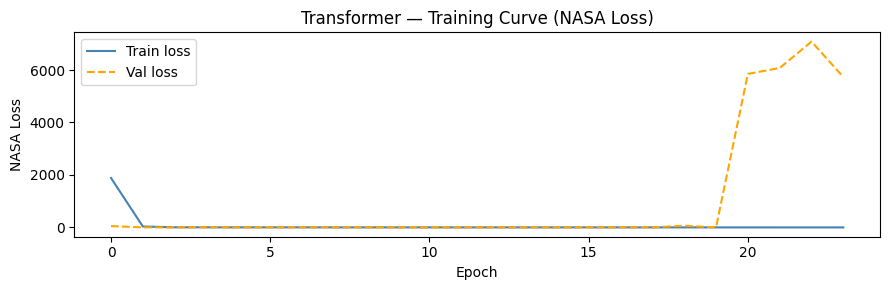

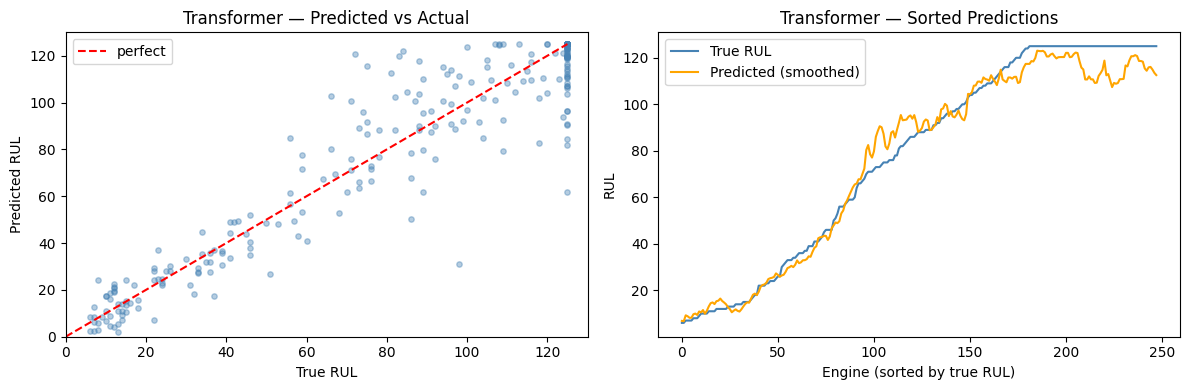

In [11]:
plot_loss_curves(train_losses, val_losses, model_name="Transformer")
plot_predictions(y_true, y_pred, model_name="Transformer")